# Autoencoders. Eliminar ruido de imágenes con TensorFlow y Keras

El objetico es crear un autoencoder con una CNN que aprende a reconstruir una imagen a partir de una versión comprimida. En este caso, lo usamos para eliminar ruido de imágenes en blanco y negro. Durante el entrenamiento, añadimos ruido a propósito para que el modelo aprenda a limpiarlas. Una vez entrenado, puede recibir una imagen con ruido real y devolver una versión más limpia.

In [1]:
# Importación bibliotecas
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Primero será necesario descomprimir el archivo y cargar las imágenes del dataset noMNIST, el cual está compartido en Drive y comprimido en formato tar.gz.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

import tarfile

# Path al archivo .tar.gz dentro del Drive
tar_path = '/content/drive/MyDrive/CURSO_MACHINE_LEARNING/CSV/notMNIST_small.tar.gz'

# Descomprimir el archivo
with tarfile.open(tar_path, 'r:gz') as tar:
    print("Descomprimiendo...")
    tar.extractall('/content/nomist')
    print("Hecho.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Descomprimiendo...
Hecho.


In [7]:
import os
print(os.listdir('/content/nomist'))

['notMNIST_small']


Obtenemos el dataset y guardamos las imágenes en un array X y las etiquetas correspondientes en y.
Estas variables nos permitirán trabajar con los datos: X contendrá las imágenes en formato numérico y y las letras asociadas a cada imagen, ya que el conjunto noMNIST incluye caracteres de la A a la J.

In [8]:
import os
import numpy as np
from PIL import Image


# Ruta donde estan las imágenes descomprimidas
dataset_dir = '/content/nomist/notMNIST_small'

# Listamos las clases disponibles en el dataset e inicializamos las listas donde iremos guardando las imágenes y sus etiquetas correspondientes.
classes = sorted(os.listdir(dataset_dir))
X, y = [], []

# Cargar y convertir cada imagen a un array para que el modelo pueda procesarlas
for label, class_dir in enumerate(classes):
    class_path = os.path.join(dataset_dir, class_dir)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            if os.path.isfile(img_path):
                try:
                    img = np.array(Image.open(img_path).convert('L'))
                    X.append(img)
                    y.append(label)
                except Exception as e:
                    print(f"No se puede abrir la imagen {img_name}: {e}")

# Convertimos las listas en arrays de NumPy
X, y = np.array(X), np.array(y)

No se puede abrir la imagen RGVtb2NyYXRpY2FCb2xkT2xkc3R5bGUgQm9sZC50dGY=.png: cannot identify image file '/content/nomist/notMNIST_small/A/RGVtb2NyYXRpY2FCb2xkT2xkc3R5bGUgQm9sZC50dGY=.png'
No se puede abrir la imagen Q3Jvc3NvdmVyIEJvbGRPYmxpcXVlLnR0Zg==.png: cannot identify image file '/content/nomist/notMNIST_small/F/Q3Jvc3NvdmVyIEJvbGRPYmxpcXVlLnR0Zg==.png'


In [9]:
# Dividimos en entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Una vez tenemos el dataset, vamos a analizar cuántas instancias hay en total y por clase

In [10]:
# Mostramos el número de imágenes y etiquetas en cada subconjunto, junto con el tamaño de las imágenes (28x28)
print("Tamaño de las características de entrenamiento = ", X_train.shape)
print("Tamaño de las etiquetas de entrenamiento = ", y_train.shape)
print("Tamaño de las características de validación = ", X_test.shape)
print("Tamaño de las etiquetas de validación = ", y_test.shape)

Tamaño de las características de entrenamiento =  (13106, 28, 28)
Tamaño de las etiquetas de entrenamiento =  (13106,)
Tamaño de las características de validación =  (5618, 28, 28)
Tamaño de las etiquetas de validación =  (5618,)


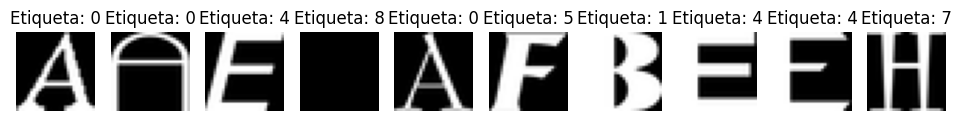

In [11]:
# Mostramos las 10 primeras imágenes del dataset
num_imagenes_mostrar = 10

plt.figure(figsize=(12, 4))
for i in range(num_imagenes_mostrar):
    plt.subplot(1, num_imagenes_mostrar, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title("Etiqueta: {}".format(y_train[i]))
    plt.axis('off')

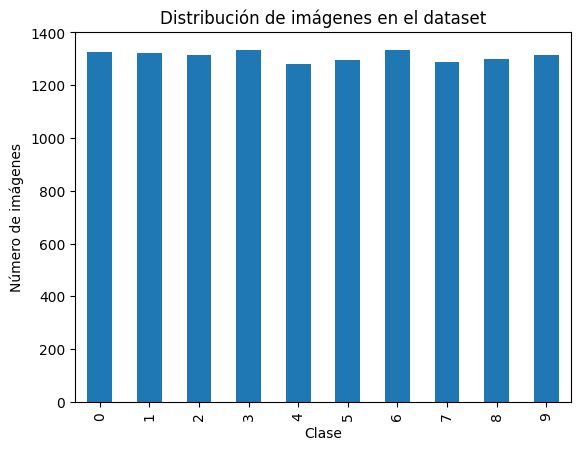

In [12]:
# El dataset noMNIST contiene solo 10 clases, correspondientes a las letras de la A a la J

# Creamos un DataFrame con las etiquetas de las imágenes de entrenamiento
df = pd.DataFrame({'Label': y_train})

# Contamos cuántas imágenes hay de cada clase y lo representamos en una gráfica de barras
num_por_clase = df['Label'].value_counts().sort_index()

num_por_clase.plot(kind='bar')
plt.xlabel('Clase')
plt.ylabel("Número de imágenes")
plt.title("Distribución de imágenes en el dataset")
plt.show()

In [13]:
# Comprobar el rango de valores de los píxeles en las imágenes,  0 (negro) y 255 (blanco) antes de normalizar
print("El valor máximo del píxel de una imagen es: {}".format(X_train.max()))
print("El valor mínimo del píxel de una imagen es: {}".format(X_train.min()))

El valor máximo del píxel de una imagen es: 255
El valor mínimo del píxel de una imagen es: 0


Como vamos a usar un autoencoder, que se entrena de forma no supervisada, no necesitaremos las etiquetas de cada clase.

Solo usaremos las imágenes, así que guardamos las características en una variable con un nombre más intuitivo.

In [14]:
# Damos un nombre más intuitivo a las variables que almacenan nuestras imágenes
imagenes_entrenamiento = X_train
imagenes_test = X_test

# Los valores de los píxeles van de 0 (negro) a 255 (blanco)
# Normalizamos las imágenes para que los valores estén entre 0 y 1
imagenes_entrenamiento = imagenes_entrenamiento.astype('float32') / 255.0
imagenes_test = imagenes_test.astype('float32') / 255.0

print("El valor máximo del píxel de una imagen de entrenamiento es: {}".format(imagenes_entrenamiento.max()))
print("El valor mínimo del píxel de una imagen de entrenamiento es: {}".format(imagenes_entrenamiento.min()))
print("El valor máximo del píxel de una imagen de validación es: {}".format(imagenes_test.max()))
print("El valor mínimo del píxel de una imagen de validación es: {}".format(imagenes_test.min()))

El valor máximo del píxel de una imagen de entrenamiento es: 1.0
El valor mínimo del píxel de una imagen de entrenamiento es: 0.0
El valor máximo del píxel de una imagen de validación es: 1.0
El valor mínimo del píxel de una imagen de validación es: 0.0


Ahora que ya tenemos las imágenes normalizadas, aplicaremos ruido para entrenar el autoencoder.

El objetivo es que aprenda a reconstruir imágenes limpias a partir de versiones ruidosas.

In [15]:
factor_ruido = 0.5

# Añadimos ruido a las imágenes sumando ruido gaussiano (media 0, desviación estándar 1)
# multiplicado por un factor de intensidad
imagenes_entrenamiento_con_ruido = imagenes_entrenamiento + factor_ruido * np.random.normal(size=imagenes_entrenamiento.shape)
imagenes_test_con_ruido = imagenes_test + factor_ruido * np.random.normal(size=imagenes_test.shape)

In [16]:
# Después de añadir el ruido, puede que algunos valores queden fuera del rango [0, 1]
# Para evitarlo, forzamos que todos los píxeles se mantengan dentro de ese rango
imagenes_entrenamiento_con_ruido = np.clip(imagenes_entrenamiento_con_ruido, 0., 1.)
imagenes_test_con_ruido = np.clip(imagenes_test_con_ruido, 0., 1.)

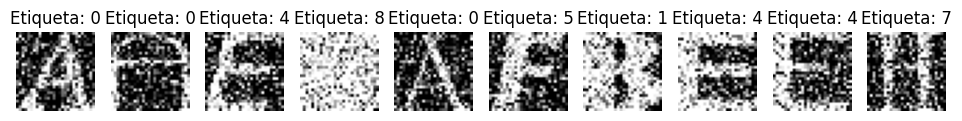

In [17]:
# Mostramos 10 imágenes con ruido para visualizar cómo han quedado tras aplicar el ruido
num_imagenes_mostrar = 10

plt.figure(figsize=(12, 4))
for i in range(num_imagenes_mostrar):
    plt.subplot(1, num_imagenes_mostrar, i + 1)
    plt.imshow(imagenes_entrenamiento_con_ruido[i], cmap='gray')
    plt.title("Etiqueta: {}".format(y_train[i]))
    plt.axis('off')

In [18]:
# Creamos una función para mostrar imágenes una vez el autoencoder esté entrenado:
# Primero se muestran las imágenes originales
# Luego las imágenes con ruido
# Finalmente las imágenes reconstruidas por el autoencoder
def mostrar_imagenes(imagenes_test, imagenes_test_con_ruido, imagenes_reconstruidas):
    num_samples = 5

    plt.figure(figsize=(15, 5))
    for i in range(num_samples):
        # Imágenes originales
        plt.subplot(3, num_samples, i + 1)
        plt.imshow(imagenes_test[i], cmap='gray')
        plt.title('Original')
        plt.axis('off')

        # Imágenes con ruido
        plt.subplot(3, num_samples, num_samples + i + 1)
        plt.imshow(imagenes_test_con_ruido[i], cmap='gray')
        plt.title('Con ruido')
        plt.axis('off')

        # Imágenes reconstruidas
        plt.subplot(3, num_samples, 2*num_samples + i + 1)
        plt.imshow(imagenes_reconstruidas[i].reshape(28, 28), cmap='gray')
        plt.title('Reconstruida')
        plt.axis('off')

    plt.show()

## Primer autoencoder: capas totalmente conectadas (*fully-connected layers*)

Ahora ya podemos crear nuestro autoencoder.

La primera arquitectura que vamos a utilizar será un autoencoder con capas totalmente conectadas (fully-connected layers).

Primero se enseña el concepto con MLP porque es más fácil, y después se mejora con CNN, que es más potente para imágenes.

Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 270ms/step - loss: 0.2087 - val_loss: 0.1881
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.1847 - val_loss: 0.1652
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1557 - val_loss: 0.1316
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1249 - val_loss: 0.1170
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1104 - val_loss: 0.1046
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1007 - val_loss: 0.0963
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0943 - val_loss: 0.0905
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0882 - val_loss: 0.0852
Epoch 9/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0847 - val_loss: 0.0871
Epoch 10/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0864 - val_loss: 0.0818
Epoch 11/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0776 - val_loss: 0.0753
Epoch 12/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.

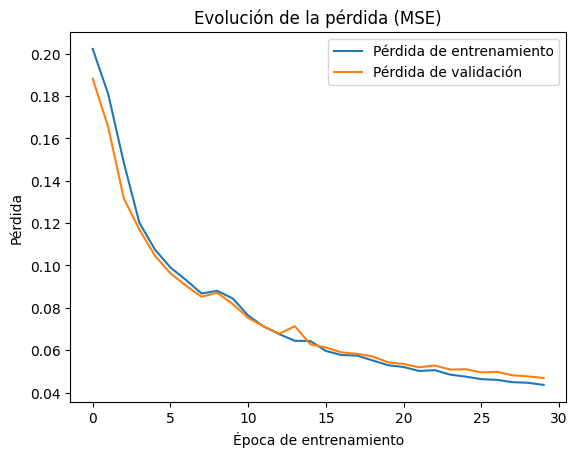

In [19]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Definimos el codificador: reduce la imagen a un espacio latente comprimido
encoder_input = Input(shape=(28 * 28,))  # 28 x 28 = 784 píxeles aplanados
encoder_dense1 = Dense(512, activation='relu')(encoder_input)
encoder_dense2 = Dense(256, activation='relu')(encoder_dense1)
encoder_dense3 = Dense(128, activation='relu')(encoder_dense2)

# Espacio latente: representación comprimida de la imagen
latent_space = Dense(64, activation='relu', name='latent_space')(encoder_dense3)
encoder_model = Model(encoder_input, latent_space)

# Definimos el decodificador: reconstruye la imagen original a partir del espacio latente
decoder_input = Input(shape=(64,))
decoder_dense1 = Dense(128, activation='relu')(decoder_input)
decoder_dense2 = Dense(256, activation='relu')(decoder_dense1)
decoder_dense3 = Dense(512, activation='relu')(decoder_dense2)
decoder_output = Dense(28 * 28, activation='sigmoid')(decoder_dense3)
decoder_model = Model(decoder_input, decoder_output)

# Creamos el modelo completo autoencoder conectando codificador y decodificador
autoencoder_input = Input(shape=(28 * 28,))
encoded = encoder_model(autoencoder_input)
decoded = decoder_model(encoded)
autoencoder_model = Model(autoencoder_input, decoded)

# Compilamos el modelo con optimizador Adam y función de pérdida MSE
autoencoder_model.compile(optimizer='adam', loss='mean_squared_error')

# Entrenamos el autoencoder con imágenes ruidosas como entrada y limpias como salida
history = autoencoder_model.fit(
    imagenes_entrenamiento_con_ruido.reshape(-1, 28 * 28),
    imagenes_entrenamiento.reshape(-1, 28 * 28),
    epochs=30,
    batch_size=1024,
    shuffle=True,
    validation_data=(
        imagenes_test_con_ruido.reshape(-1, 28 * 28),
        imagenes_test.reshape(-1, 28 * 28)
    )
)

# Mostramos gráficamente la evolución de la función de pérdida durante el entrenamiento
plt.plot(history.history['loss'], label="Pérdida de entrenamiento")
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Evolución de la pérdida (MSE)')
plt.xlabel("Época de entrenamiento")
plt.ylabel('Pérdida')
plt.legend()
plt.show()

In [20]:
# Usamos el autoencoder para eliminar el ruido de las imágenes de test
imagenes_reconstruidas = autoencoder_model.predict(imagenes_test_con_ruido.reshape(-1, 28 * 28))

176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


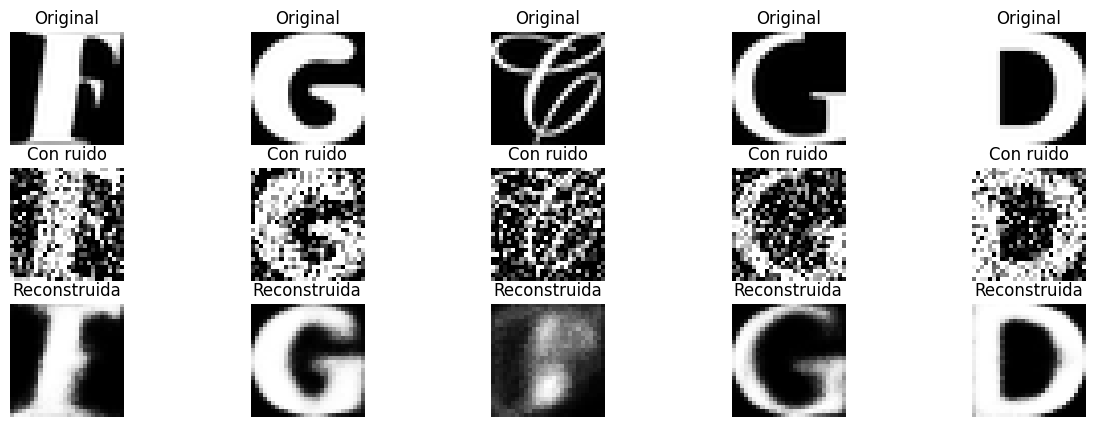

In [21]:
# Mostramos una comparación visual entre las imágenes originales, con ruido y reconstruidas por el autoencoder
mostrar_imagenes(imagenes_test, imagenes_test_con_ruido, imagenes_reconstruidas)

Hemos podido observar que el modelo ha hecho un buen trabajo eliminando el ruido. Sin embargo, aún se puede mejorar. Ahora repetiremos el proceso utilizando una Red Neuronal Convolucional (CNN).


## Autoencoder con capas convolucionales

Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 369ms/step - loss: 0.6656 - val_loss: 0.4709
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.4258 - val_loss: 0.3570
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.3398 - val_loss: 0.3063
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.2986 - val_loss: 0.2766
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.2727 - val_loss: 0.2596
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.2575 - val_loss: 0.2502
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.2498 - val_loss: 0.2457
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.2437 - val_loss: 0.2376
Epoch 9/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.2359 - val_loss: 0.2328
Epoch 10/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.2330 - val_loss: 0.2289
Epoch 11/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.2288 - val_loss: 0.2257
Epoch 12/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0

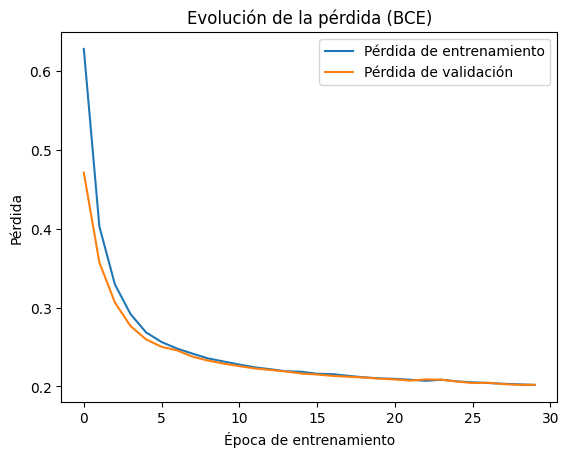

In [22]:
# Importamos las capas necesarias para definir una red convolucional
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Flatten, Dense, Reshape
from tensorflow.keras.models import Model

# Definimos la arquitectura del autoencoder convolucional
input_img = Input(shape=(28, 28, 1))  # Entrada: imagen 28x28 en escala de grises

# Codificador
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# Decodificador
x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Definimos el modelo completo
autoencoder_cnn = Model(input_img, decoded)

# En este caso, usamos la función de pérdida "binary crossentropy"
autoencoder_cnn.compile(optimizer='adam', loss='binary_crossentropy')

# Entrenamos el autoencoder convolucional
history = autoencoder_cnn.fit(
    imagenes_entrenamiento_con_ruido.reshape(-1, 28, 28, 1),
    imagenes_entrenamiento.reshape(-1, 28, 28, 1),
    epochs=30,
    batch_size=1024,
    shuffle=True,
    validation_data=(
        imagenes_test_con_ruido.reshape(-1, 28, 28, 1),
        imagenes_test.reshape(-1, 28, 28, 1)
    )
)

# Mostramos gráficamente la evolución de la función de pérdida (binary crossentropy)
plt.plot(history.history['loss'], label="Pérdida de entrenamiento")
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Evolución de la pérdida (BCE)')
plt.xlabel("Época de entrenamiento")
plt.ylabel('Pérdida')
plt.legend()
plt.show()


In [23]:
# Usamos el nuevo autoencoder convolucional para eliminar el ruido de las imágenes
imagenes_reconstruidas_cnn = autoencoder_cnn.predict(imagenes_test_con_ruido.reshape(-1, 28, 28, 1))

176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


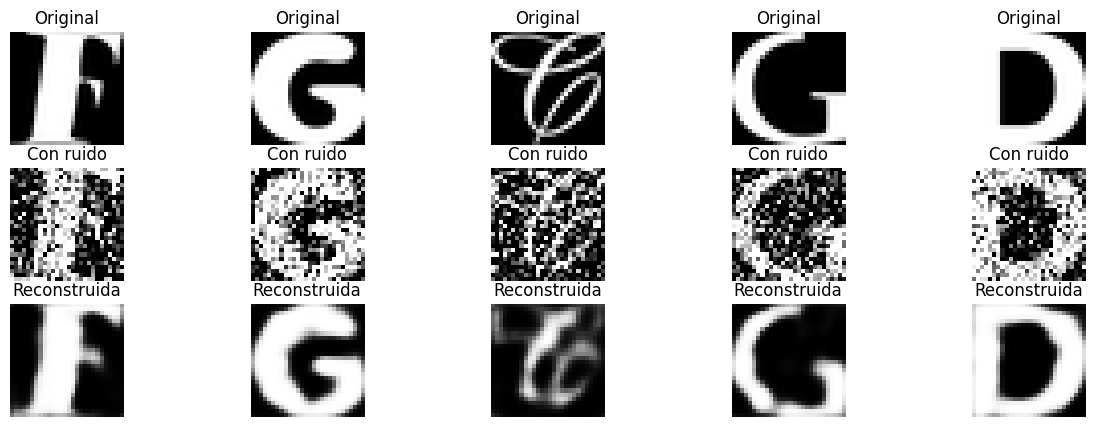

In [24]:
# Mostramos una comparación visual entre imágenes originales, con ruido y reconstruidas por el autoencoder CNN
mostrar_imagenes(imagenes_test, imagenes_test_con_ruido, imagenes_reconstruidas_cnn)

## Validación cualitativa con imágenes externas al dataset


Para comprobar si el modelo ha generalizado correctamente, vamos a observar cómo se comporta  al procesar imágenes generadas con otro programa que no representan números


Saving letra.png to letra (3).png
Archivo subido correctamente: letra (3).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


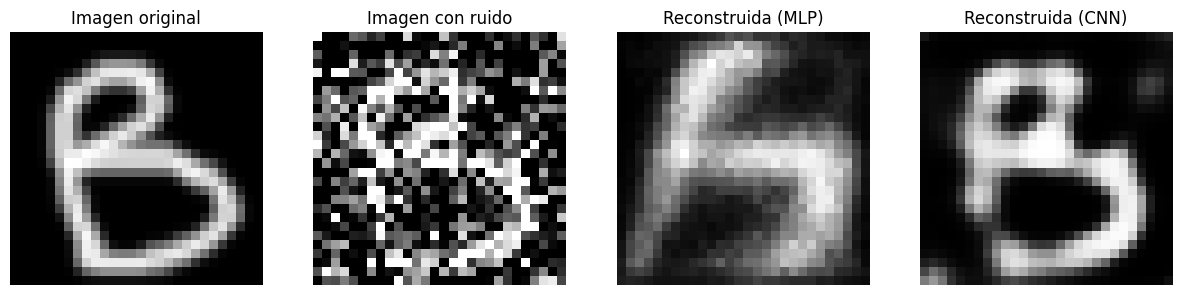

In [28]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Subir archivo
uploaded = files.upload()

# Procesar la imagen subida
for file_name in uploaded.keys():
    print(f"Archivo subido correctamente: {file_name}")

    # Abrir y convertir a escala de grises
    img = Image.open(file_name)
    imagen_gris = img.convert('L')

    # Redimensionar a 28x28 píxeles
    imagen_redimensionada = imagen_gris.resize((28, 28))

    # Convertir a array NumPy
    imagen_array = np.array(imagen_redimensionada)

    # Normalizar la imagen
    imagen_normalizada = imagen_array.astype('float32') / 255.0

    # Añadir ruido
    factor_ruido = 0.5
    imagen_con_ruido = imagen_normalizada + factor_ruido * np.random.normal(size=imagen_normalizada.shape)
    imagen_con_ruido = np.clip(imagen_con_ruido, 0., 1.)

    # --- Predicción con autoencoder MLP ---
    imagen_denoised_mlp = autoencoder_model.predict(imagen_con_ruido.reshape(1, 28 * 28))

    # --- Predicción con autoencoder CNN ---
    imagen_denoised_cnn = autoencoder_cnn.predict(imagen_con_ruido.reshape(1, 28, 28, 1))

    # Mostrar resultados
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(imagen_normalizada, cmap='gray')
    plt.title('Imagen original')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(imagen_con_ruido.reshape(28, 28), cmap='gray')
    plt.title('Imagen con ruido')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(imagen_denoised_mlp.reshape(28, 28), cmap='gray')
    plt.title('Reconstruida (MLP)')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(imagen_denoised_cnn.reshape(28, 28), cmap='gray')
    plt.title('Reconstruida (CNN)')
    plt.axis('off')

    plt.show()


# Imagen con ruido

Saving letra2_con_ruido.png to letra2_con_ruido.png
Imagen subida: letra2_con_ruido.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


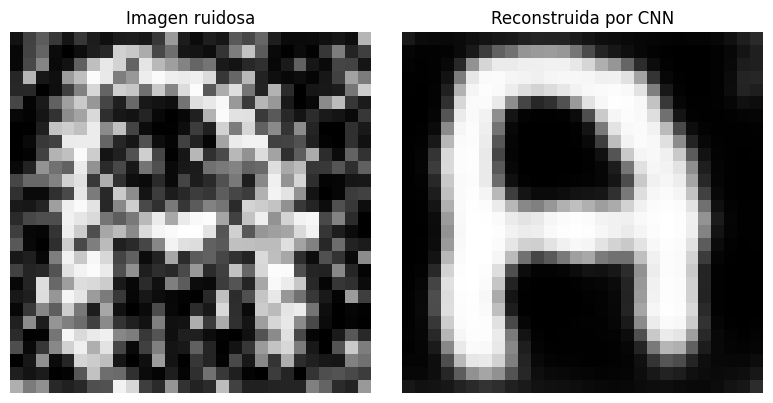

In [31]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Subir imagen ruidosa
uploaded = files.upload()

for file_name in uploaded.keys():
    print(f"Imagen subida: {file_name}")

    # Cargar y convertir a escala de grises
    img = Image.open(file_name).convert('L')

    # Redimensionar a 28x28 píxeles
    img_resized = img.resize((28, 28))

    # Convertir a array NumPy y normalizar
    img_array = np.array(img_resized).astype('float32') / 255.0

    # Pasar la imagen directamente por el autoencoder CNN
    img_denoised = autoencoder_cnn.predict(img_array.reshape(1, 28, 28, 1))

    # Mostrar imagen original ruidosa y la reconstruida
    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img_array, cmap='gray')
    plt.title("Imagen ruidosa")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_denoised.reshape(28, 28), cmap='gray')
    plt.title("Reconstruida por CNN")
    plt.axis('off')

    plt.tight_layout()
    plt.show()
